In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import os
import json 
import pickle
from models import ContrastiveCritic
# from rnd_jax import RND
# from icm_jax import ICM
# from apt_jax_sac import Aptcritic
from etils import epath
import argparse 
from utils import create_env
from concurrent.futures import ThreadPoolExecutor, as_completed


## Paths for extracting checkpoints and visited states

In [3]:
# make sure the path is correct, you only need to specify the run_name
states_run_dir = "/network/scratch/f/faisal.mohamed/crl_runs/ctec_sac/ant_hardest_maze/ctec/1763060026_sandal"
visited_states_path = os.path.join(states_run_dir, "visited_states")
# args filename
run_dir = "/network/scratch/f/faisal.mohamed/crl_runs/ctec_sac/ant_hardest_maze/ctec/1763060026_sandal"
args_filePath = os.path.join(run_dir, "args.json")
# params_path = os.path.join(run_dir, "ckpt_sac_761856.pkl")
seed = 75984637
rng = jax.random.PRNGKey(seed)
pick_ranodm_starting_state = False
os.makedirs("maze_visuals", exist_ok=True)
pick_a_goal_state=True
use_ema = True
fix_goal = False
is_sim_reward = False
compute_full_infonce_reward=False
model_type="crl"

In [4]:
# helper function to load the model
def load_params(path: str):
    with epath.Path(path).open('rb') as fin:
        buf = fin.read()
    return pickle.loads(buf)

def load_args(path: str):
    with open(path, 'rb') as fin:
        return dict_to_args(json.load(fin))
    

def load_visited_state(path, number_of_files=10, random_pickup=False):
    dir_list = np.array(os.listdir(path))
    all_states = []
    if number_of_files:
        if random_pickup:
            rand_inds = np.random.choice(len(dir_list), number_of_files, replace=False)
        # import pdb; pdb.set_trace()
            dir_list = dir_list[rand_inds]
        else:
            dir_list = dir_list[:number_of_files]
    for dr in dir_list:
        if dr.endswith(".npz"):
            states = np.load(os.path.join(path, dr))["data"]
            all_states.append(states)
    all_states_np = np.concatenate(all_states, axis=0)
    return all_states_np


def load_buffer_data(path, number_of_files=10):
    dir_list = np.array(os.listdir(path))
    all_states = []
    if number_of_files:
        rand_inds = np.random.choice(len(dir_list), number_of_files, replace=False)
    # import pdb; pdb.set_trace()
        dir_list = dir_list[rand_inds]
    for dr in dir_list:
        if dr.endswith(".npz"):
            states = np.load(os.path.join(path, dr))["data"]
            all_states.append(states)
    all_states_np = np.concatenate(all_states, axis=0)
    rand_inds = np.random.choice(all_states_np.shape[0], all_states_np.shape[0], replace=False)
    return all_states_np[rand_inds]

def dict_to_args(d: dict) -> argparse.Namespace:
    """
    Convert a dictionary back to an argparse.Namespace.
    (Note: if the dict values were converted to JSON-friendly types, 
    they will remain as such; converting back to a JAX array would require extra steps.)
    """
    return argparse.Namespace(**d)

def create_model(config):
    return ContrastiveCritic(config)

def extract_model(run_dir, use_ema=False):
    ckpt_dir = os.path.join(run_dir, "ckpt")   
    dir_lis = os.listdir(ckpt_dir)
    if use_ema:
        params_path =os.path.join(ckpt_dir, "sac_crl_ema.pkl")  
    else:
        params_path =os.path.join(ckpt_dir, "sac_crl_final.pkl")  
    args = load_args(args_filePath) 
    params = load_params(params_path)
    model = create_model(args)
    return model, params, args

def extract_rnd_model(run_dir, use_ema=False):
    ckpt_dir = os.path.join(run_dir, "ckpt")   
    dir_lis = os.listdir(ckpt_dir)
    if use_ema:
        params_path =os.path.join(ckpt_dir, "sac_crl_ema.pkl")  
    else:
        params_path =os.path.join(ckpt_dir, "sac_rnd_final.pkl")  
    args = load_args(args_filePath) 
    params = load_params(params_path)
    model = RND(args)
    return model, params, args

def extract_icm_model(run_dir, use_ema=False):
    ckpt_dir = os.path.join(run_dir, "ckpt")   
    dir_lis = os.listdir(ckpt_dir)
    if use_ema:
        params_path =os.path.join(ckpt_dir, "sac_crl_ema.pkl")  
    else:
        params_path =os.path.join(ckpt_dir, "sac_rnd_final.pkl")  
    args = load_args(args_filePath) 
    params = load_params(params_path)
    model = RND(args)
    return model, params, args

def extract_apt_model(run_dir, use_ema=False):
    ckpt_dir = os.path.join(run_dir, "ckpt")   
    dir_lis = os.listdir(ckpt_dir)
    if use_ema:
        params_path =os.path.join(ckpt_dir, "sac_crl_ema.pkl")  
    else:
        params_path =os.path.join(ckpt_dir, "sac_crl_final.pkl")  
    args = load_args(args_filePath) 
    params = load_params(params_path)
    model = Aptcritic(args)
    return model, params, args
### Testing
# args = (load_args(args_filePath)    )
# args.critic_lr
# load_params(params_path) 
# visited_states_path = f"{run_dir}/visited_states"
# load_buffer_data()

In [5]:
# # _, _, args = extract_model(run_dir, use_ema=use_ema)
# # 
# # env = create_env(args)
# number_of_files = 15
# all_states = jnp.array(load_visited_state(visited_states_path, number_of_files))

# num_states = 1000_000
# rand_inds = np.random.choice(len(all_states), num_states, replace=False)
# all_states_visual = all_states[rand_inds]
# plt.figure(figsize=(7, 5))
# plt.scatter(all_states_visual[:, 0], all_states_visual[:, 1],alpha=0.3)
# method = "RND"
# env_name = "humanoid_u_maze"
# plt.title(f"{method} Coverage on {env_name}")
# plt.axis('off')
# plt.xlim([-1.5, 7])
# plt.ylim([-2.5, 7])
# plt.savefig(f"maze_visuals/{method} Coverage on {env_name}.pdf", dpi=200)

In [6]:
def crl_reward(contrastive_network, contrastive_params, state, action, future_state, args, key_critic, compute_full_infonce_reward):
    goal = future_state

    # import pdb;pdb.set_trace()
# /    import pdb;pdb.set_trace()
    sa_repr, g_repr, _ = contrastive_network.apply(contrastive_params, state, action, goal, key_critic, args.da)

    similarity_method_outer = {
            "l2": lambda sa_repr, g_repr: -jnp.sqrt(jnp.sum((sa_repr[ :, None, :] - g_repr[None, :, :]) ** 2, axis=-1)),
            "l2_no_sqrt":  lambda sa_repr, g_repr: -jnp.sum((sa_repr[ :, None, :] - g_repr[None, :, :]) ** 2, axis=-1),
            "l1":  lambda sa_repr, g_repr: -jnp.sum(jnp.abs(sa_repr[ :, None, :] - g_repr[None, :, :]), axis=-1),
            "dot": lambda sa_repr, g_repr: jnp.einsum("ik,jk->ij", sa_repr, g_repr), # if the vectors are normalized then this the cosine 
        }
    similarity_method = {
            "l2": lambda sa_repr, g_repr: -jnp.sqrt(jnp.sum((sa_repr - g_repr) ** 2, axis=-1)),
            "l2_no_sqrt":  lambda sa_repr, g_repr: -jnp.sum((sa_repr - g_repr) ** 2, axis=-1),
            "l1":  lambda sa_repr, g_repr: -jnp.sum(jnp.abs(sa_repr - g_repr), axis=-1),
            "dot": lambda sa_repr, g_repr: jnp.einsum("ik,jk->i", sa_repr, g_repr), # if the vectors are normalized then this the cosine 
        }
    # print(sa_repr)
    # print(g_repr)
    sm = (similarity_method[args.energy_fn](sa_repr, g_repr))
    reward = -sm
        # import pdb;pdb.set_trace()
    return  jax.lax.stop_gradient(reward)

In [7]:
def apt_reward(contrastive_network, contrastive_params, state, action, future_state, args, key_critic, compute_full_infonce_reward):
    goal = future_state
    
    sa_repr, _, _ = contrastive_network.apply(contrastive_params, goal, action, goal, key_critic, args.da)
    # similarity_method = {
    #         "l2": lambda sa_repr, g_repr: -jnp.sqrt(jnp.sum((sa_repr - g_repr) ** 2, axis=-1)),
    #         "l2_no_sqrt":  lambda sa_repr, g_repr: -jnp.sum((sa_repr - g_repr) ** 2, axis=-1),
    #         "l1":  lambda sa_repr, g_repr: -jnp.sum(jnp.abs(sa_repr - g_repr), axis=-1),
    #         "dot": lambda sa_repr, g_repr: jnp.einsum("ik,jk->i", sa_repr, g_repr), # if the vectors are normalized then this the cosine 
    #     }
    
    # sm = (similarity_method[args.energy_fn](sa_repr, g_repr))
    k = 12
    dists = jnp.sum((sa_repr[:, None, :] - sa_repr[ None, :, :]) ** 2, axis=-1)

    # Sort the distances for each point
    sorted_dists = jnp.sort(dists, axis=-1)

    # Iterate over the ks to compute the k-NN distances and accumulate them

    knn_dists = sorted_dists[:, 1:k+1]  # First distance is to the point itself, so skip it
    mean_knn_dists = jnp.mean(knn_dists, axis=-1)  # Mean distance to k nearest neighbors
    reward = mean_knn_dists
    # reward = -sm
        # import pdb;pdb.set_trace()
    return  jax.lax.stop_gradient(reward)

In [8]:
if "crl" in model_type:
    model, params, args = extract_model(run_dir, use_ema=use_ema)
elif "apt" in model_type:
    model, params, args = extract_apt_model(run_dir, use_ema=use_ema)
num_states = 20_000
env = create_env(args)
number_of_files = 10
random_state=False
all_states = jnp.array(load_visited_state(visited_states_path, number_of_files, random_state))

this ant maze


In [7]:
all_states.shape

(10240000, 2)

In [9]:
number_of_states = np.logspace(5, np.log(len(all_states)), base=2.8, num=10, dtype=np.int64, endpoint=True)
print(number_of_states)

[     172      615     2202     7879    28188   100844   360764  1290613
  4617093 16517372]


this ant maze


/tmp/ipykernel_1261786/3960057902.py:22: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  buf      = fig.canvas.tostring_rgb()                      # as RGB bytes


KeyboardInterrupt: 

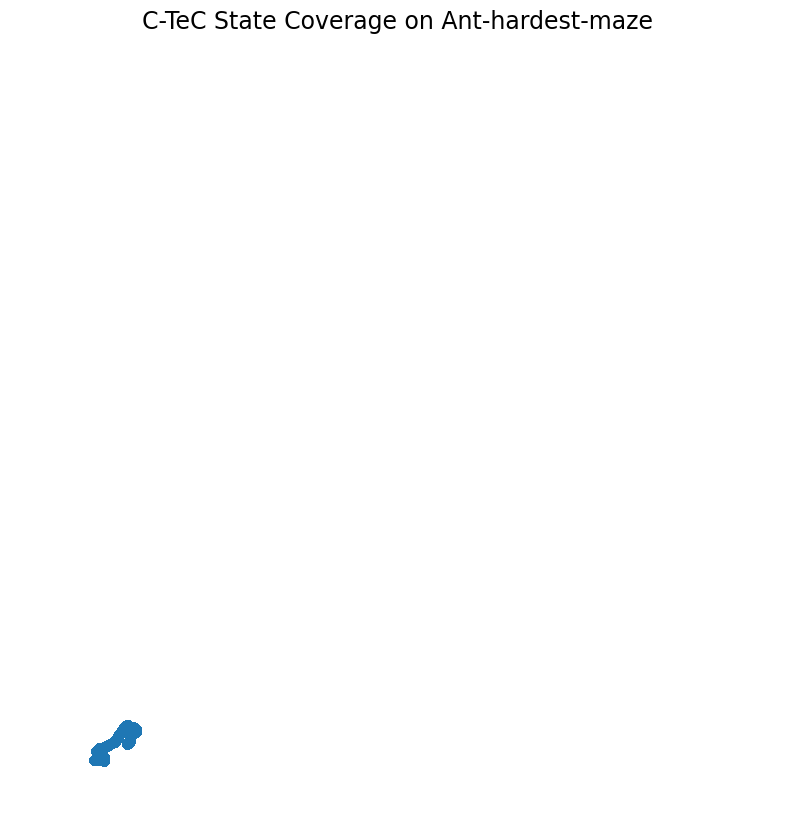

In [10]:

env = create_env(args)
random_state=False
number_of_states = np.logspace(5, np.log(len(all_states)), base=2.8, num=100, dtype=np.int64, endpoint=True)
figures = []
font_size = 17
for number_of_states in number_of_states:
    rng, rng_ = jax.random.split(rng)
    all_states_ = all_states[:number_of_states]
    num_states = 200_000
    inds = jax.random.choice(rng_, number_of_states, shape=(num_states, ))
    all_states_ = all_states_[inds]
    fig, ax = plt.subplots(figsize=(10, 10))
    # 2. Do your plotting
    ax.scatter(all_states_[:, 0], all_states_[:, 1])
    ax.set_xlim(0, 38)
    ax.set_ylim(0, 45)
    ax.axis("off")
    ax.set_title("C-TeC State Coverage on Ant-hardest-maze", fontdict={"size": font_size})
    fig.canvas.draw()
    # 4. Extract the pixel buffer as a 1D uint8 array, then reshape
    width, height = fig.canvas.get_width_height()
    buf      = fig.canvas.tostring_rgb()                      # as RGB bytes
    img_arr  = np.frombuffer(buf, dtype=np.uint8)             # flat array
    img_arr  = img_arr.reshape((height, width, 3)) 
    figures.append(img_arr)
    base_dir = "state_coverage_over_training"
    os.makedirs(base_dir, exist_ok=True)
    plt.savefig(f"{base_dir}/ctec_tate_coverage_on_ant_number_of_state_files={number_of_states}.png", dpi=300)
    plt.savefig(f"{base_dir}/ctec_tate_coverage_on_ant_number_of_state_files={number_of_states}.pdf", dpi=300)
    plt.close()

In [ ]:
import imageio

imageio.mimsave(f"{base_dir}/coverage_over_time.gif", figures, fps=15)

In [11]:
rng, rng_ = jax.random.split(rng)
num_states_reward = 10_000
num_state_visual = 10_000
num_states = 20_000
if fix_goal:
    rand_indices = jax.random.choice(rng_, observations.shape[0], shape=(num_states_reward, ), replace=False)   
    obs_repeated = observations[rand_indices, :args.obs_dim]
    action = jnp.zeros((obs_repeated.shape[0], args.action_dim))
    rand_ind = jax.random.choice(rng_, all_states.shape[0], shape=(1, ), replace=False)   
    goal = all_states[rand_ind]
    goal = jnp.repeat(goal, obs_repeated.shape[0], axis=0)
    print(obs_repeated.shape)
    print(action.shape)
    print(goal.shape)
    
else:
    state = env.reset(rng)
    rand_indices = jax.random.choice(rng, all_states.shape[0], shape=(num_states, ), replace=False)   
    all_states = all_states[rand_indices]  
    # pick a random observation 
    rng, rng_ = jax.random.split(rng)
    goal_dim = len(args.crl_goal_indices)
    if pick_ranodm_starting_state:
        print(jax.random.randint(rng, (1, ), 0, all_states.shape[0]))
        obs = all_states[jax.random.randint(rng_, (1, ), 0, all_states.shape[0])[0]] 
        obs = state.obs.at[:goal_dim].set(obs)
        # print(obs)
    else:
        obs = state.obs

    obs_repeated = jnp.repeat(obs[None, :args.obs_dim], all_states.shape[0], axis=0)
    # print(obs_repeated[0])
    # action = jax.random.uniform(rng_, (all_states.shape[0], args.action_dim)) 
    action = jnp.zeros((all_states.shape[0], args.action_dim))
    print(obs_repeated.shape)
    print(action.shape)
    print(all_states.shape)

(20000, 29)
(20000, 8)
(20000, 2)


In [ ]:
args.model

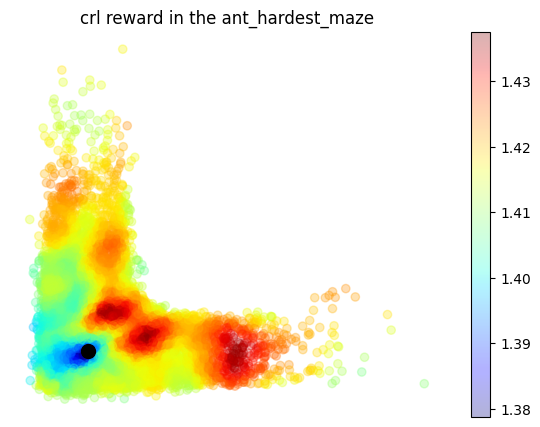

In [ ]:
# model, params, args = extract_model(run_dir, use_ema=use_ema)

if fix_goal:
    # plot heatmap of the contrastive rewardf
    rand_indices = jax.random.permutation(rng, jnp.arange(obs_repeated.shape[0]))[:num_state_visual]  
    all_states_visual  = obs_repeated[rand_indices]
    crl_rewards = crl_reward(model, params, all_states_visual, action[rand_indices], goal[rand_indices], args, rng, compute_full_infonce_reward)
    print(crl_rewards[rand_indices].shape)
    plt.figure(figsize=(7, 5))
    plt.scatter(all_states_visual[:, 0], all_states_visual[:, 1], c=crl_rewards, cmap="jet", alpha=0.5)
    plt.colorbar()
    plt.scatter(goal[0, 0], goal[0, 1], c="black", s=100)
    plt.title(f"Contrastive reward in the {args.env_name} similarity_reward:{is_sim_reward} fixed_goal:{fix_goal} ema:{use_ema}")       
    plt.axis('off')
    plt.savefig(f"maze_visuals/Contrastive reward in the {args.env_name} similarity_reward:{is_sim_reward} fixed_goal:{fix_goal} ema:{use_ema}.png")
else:
    # if "crl" in args.model:
    crl_rewards = crl_reward(model, params, obs_repeated, action, all_states, args, rng, True)
    # elif "apt" in args.model:
    #     obs_repeated[:,:2]
    #     crl_rewards = apt_reward(model, params, all_states, action, all_states, args, rng, True)
    # plot heatmap of the contrastive rewardf
    rand_indices = jax.random.permutation(rng, jnp.arange(all_states.shape[0]))[:num_states]  
    all_states_visual  = all_states[rand_indices, :goal_dim]
    plt.figure(figsize=(7, 5))
    plt.scatter(all_states_visual[:, 0], all_states_visual[:, 1], c=crl_rewards[rand_indices], cmap="jet", alpha=0.3)
    plt.colorbar()
    plt.scatter(obs[0], obs[1], c="black", s=100)
    plt.title(f"{model_type} reward in the {args.env_name}")
    plt.axis('off')
    plt.savefig(f"maze_visuals/{model_type} reward in the {args.env_name}.png")

    